# Benchmark
---
- Use K-Nearest Neighbors (KNN) with rule-based engineered features as the baseline for the SpellSpark models
- Sanity Check: Deep learning models (especially, BiLSTM and CNN which planned to use for SpellSpark) are complex. If the neural networks cannot beat the simple KNN baseline, it signals that either the network architecture needs tuning, or the data doesn't have enough complex patterns to justify deep learning.

---


# Workflow Overview: Inputs, Outputs, and Data Flow

This notebook uses a teacher-student setup to predict error-profile distributions for words.

## 1) Raw Data Load

- Input: Excel file at `DATA_PATH`.
- Output: `df` with columns including `correct`, `incorrect`, and `error_type`.
- How: read the Excel file into a pandas DataFrame for downstream feature construction.

## 2) Model 1 Feature Builder (Teacher Inputs)

- Input: each row of `df` (`correct`, `incorrect`).
- Output:
  - `X_m1` (feature matrix for teacher model)
  - `y` (hard class labels from `df['error_type']`)
- How: compute engineered pair-level features from correct/misspelled word pairs and extract class labels.

## 3) Shared Train/Test Split (Used by Both Models)

- Input: row indices and labels `y` for stratification.
- Output: `train_idx`, `test_idx`.
- How: create one stratified split and reuse the same indices for both teacher and student pipelines.

## 4) Teacher Model (Model 1) Training

- Input:
  - `X_m1[train_idx]` -> scaled as `X_m1_train_scaled`
  - `y[train_idx]` -> `y_train_hard`
- Output: trained teacher model `teacher_m1`.
- How: scale Model 1 features and fit a KNN classifier on the training subset.

## 5) Soft Label Generation ("True" Profiles)

- Input: trained `teacher_m1` and full scaled features `X_m1_all_scaled`.
- Output:
  - `true_profiles_all` from `teacher_m1.predict_proba(...)`
  - `y_train_profiles = true_profiles_all[train_idx]`
  - `y_test_profiles = true_profiles_all[test_idx]`
- How: run teacher probability inference for each record, then slice into train/test using shared indices.

## 6) Model 2 Feature Builder (Student Inputs)

- Input: `df['correct']` only.
- Output:
  - `X_m2` (student feature matrix)
  - `X_train_m2_scaled`, `X_test_m2_scaled`
- How: compute word-level engineered features from the correct word and scale them with training-fit statistics.

## 7) Student Model (Model 2) Training

- Input:
  - features: `X_train_m2_scaled`
  - targets: `y_train_profiles` (teacher-generated soft labels)
- Output: trained student model `model2_profile`.
- How: fit a KNN regressor to map Model 2 features to full probability-profile vectors.

## 8) Test-Time Predictions

- Input: `X_test_m2_scaled`.
- Output:
  - `y_pred_profiles_test` (student predicted profile per test record)
  - `y_true_profiles_test` (teacher-generated profile for same test records)
- How: infer student profiles on test features and align against teacher test profiles by index.

## 9) Evaluation Outputs

- Input: `y_true_profiles_test` and `y_pred_profiles_test`.
- Output:
  - `mean_kl_batchmean` (PyTorch batchmean KL, comparable to your BiLSTM notebook)
  - `kl_per_sample` (per-record KL values)
  - `cos_per_sample` (per-record cosine similarity values)
  - `comparison_df` (table with per-record true/pred profiles + metric columns)
- How: compute distribution-level agreement metrics and store both summary and record-level diagnostics.

## 10) Final Artifacts

- Input: metric arrays and comparison table from evaluation.
- Output: printed summary metrics, ranked diagnostics table, and distribution plots.
- How: report aggregate performance and visualize error-profile alignment behavior across the test set.

In [9]:
import pandas as pd
import numpy as np
import re
import nltk
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, log_loss

# Download NLTK resources for edit distance
nltk.download('punkt')

DATA_PATH = '../../data/final_pairs_with_error_labels_WIP_for_INSPECTIONs.xlsx'

# Load the dataset
df = pd.read_excel(DATA_PATH)

print("Data loaded successfully. Shape:", df.shape)
df.head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\15196\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Data loaded successfully. Shape: (3468, 3)


,correct,incorrect,error_type
0,apennines,apenines,missing_letter
1,apennines,appenines,complex/multiple
2,athenian,athenean,phoneme_substitution
3,athenians,atheneans,phoneme_substitution
4,bernoulli,bernouilli,extra_letter


In [10]:
import difflib

def extract_model1_features(row):
    correct = str(row['correct']).lower() # Updated to match your column name
    misspelled = str(row['incorrect']).lower() # Updated to match your column name
    
    # 1. Length metrics
    len_correct = len(correct)
    len_diff = len(misspelled) - len_correct
    
    # 2. Distance and Similarity
    edit_dist = nltk.edit_distance(correct, misspelled)
    # difflib ratio gives a float between 0 and 1 measuring sequence similarity
    sim_ratio = difflib.SequenceMatcher(None, correct, misspelled).ratio()
    
    # 3. Positional Error Features
    same_start = 1 if (len(correct)>0 and len(misspelled)>0 and correct[0] == misspelled[0]) else 0
    same_end = 1 if (len(correct)>0 and len(misspelled)>0 and correct[-1] == misspelled[-1]) else 0
    
    # Find the index of the first character that differs
    min_len = min(len_correct, len(misspelled))
    first_diff_idx = min_len
    for i in range(min_len):
        if correct[i] != misspelled[i]:
            first_diff_idx = i
            break
    # Normalize the index by word length so it scales well
    relative_error_pos = first_diff_idx / max(len_correct, 1)
    
    # 4. Character N-gram overlap (captures if letters were just swapped)
    correct_bigrams = set([correct[i:i+2] for i in range(len(correct)-1)])
    miss_bigrams = set([misspelled[i:i+2] for i in range(len(misspelled)-1)])
    overlap = len(correct_bigrams.intersection(miss_bigrams))
    jaccard_bigram = overlap / max(len(correct_bigrams.union(miss_bigrams)), 1)
    
    return [
        edit_dist, len_correct, len_diff, sim_ratio, 
        same_start, same_end, relative_error_pos, jaccard_bigram
    ]

print("Extracting expanded features for Model 1...")
# Update y to target your actual column name
X_m1 = np.array(df.apply(extract_model1_features, axis=1).tolist())
y = df['error_type'].values

# Train/Test Split & Scaling remains exactly the same
X_train_m1, X_test_m1, y_train, y_test = train_test_split(X_m1, y, test_size=0.2, random_state=42)
scaler_m1 = StandardScaler()
X_train_m1_scaled = scaler_m1.fit_transform(X_train_m1)
X_test_m1_scaled = scaler_m1.transform(X_test_m1)

Extracting expanded features for Model 1...


In [11]:
# Initialize and train KNN for Model 1 (profile-first baseline)
# Use distance weighting so closer neighbors contribute more to the profile.
knn_m1 = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn_m1.fit(X_train_m1_scaled, y_train)

# Hard predictions (for classification metrics)
y_pred_m1 = knn_m1.predict(X_test_m1_scaled)

# Soft predictions (this is the error profile distribution)
y_prob_m1 = knn_m1.predict_proba(X_test_m1_scaled)

print("--- Model 1 Baseline (KNN) Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_m1):.4f}")
print(f"Log Loss (Distribution Error): {log_loss(y_test, y_prob_m1):.4f}\\n")
print(classification_report(y_test, y_pred_m1))

# Quick profile sanity check: each row should sum to 1.0
print("Profile row sums (first 3):", y_prob_m1[:3].sum(axis=1))

--- Model 1 Baseline (KNN) Results ---
Accuracy: 0.9063
Log Loss (Distribution Error): 1.6152\n
                      precision    recall  f1-score   support

    complex/multiple       0.93      0.95      0.94       195
        extra_letter       1.00      0.98      0.99       103
      missing_letter       0.99      0.97      0.98       217
phoneme_substitution       0.78      0.88      0.83       132
        substitution       0.50      0.34      0.41        47

            accuracy                           0.91       694
           macro avg       0.84      0.82      0.83       694
        weighted avg       0.90      0.91      0.90       694

Profile row sums (first 3): [1. 1. 1.]


In [12]:
# first three profiles for inspection
for i in range(3):
    print(f"Sample {i+1}:")
    print(f"Correct: {df.iloc[i]['correct']}, Misspelled: {df.iloc[i]['incorrect']}")
    print(f"Predicted Profile: {y_prob_m1[i]}")
    print(f"Predicted Class: {y_pred_m1[i]}, True Class: {y_test[i]}")
    print("-" * 50)

Sample 1:
Correct: apennines, Misspelled: apenines
Predicted Profile: [1. 0. 0. 0. 0.]
Predicted Class: complex/multiple, True Class: complex/multiple
--------------------------------------------------
Sample 2:
Correct: apennines, Misspelled: appenines
Predicted Profile: [0. 1. 0. 0. 0.]
Predicted Class: extra_letter, True Class: extra_letter
--------------------------------------------------
Sample 3:
Correct: athenian, Misspelled: athenean
Predicted Profile: [0. 0. 1. 0. 0.]
Predicted Class: missing_letter, True Class: missing_letter
--------------------------------------------------


In [13]:
# pd.DataFrame(y_prob_m1).to_csv("TEMP_model1_prob_distribution.csv", index=False)

### Model 1: The Mistake Classifier

- The Takeaway: High overall accuracy (90.6%), but it fails to understand phonetics.
- Why it scored so high: The engineered features (edit distance, length differences) are basically cheat codes for structural errors. An extra_letter always has a length difference of +1 and an edit distance of 1. The KNN easily clustered these together, resulting in near-perfect F1-scores for missing and extra letters.
- The glaring weakness: Look at substitution (41% F1) and phoneme_substitution (83% F1). The KNN struggles to tell these apart. Because swapping "c" for "k" (phonetic) and swapping "c" for "z" (regular substitution) look mathematically identical to the KNN — both have an edit distance of 1 and a length difference of 0.
- How the BiLSTM could possibly beat this: The KNN is blind to character meaning. The character-level BiLSTM, by learning character embeddings, will naturally learn that "c" and "k" appear in similar phonetic contexts, allowing it to correctly separate phonetic substitutions from random keystroke errors.

In [18]:
# Teacher-Student setup with a shared split
from sklearn.neighbors import KNeighborsRegressor

# Feature extraction function for Model 2 (The Predictor)
def extract_model2_features(word):
    word = str(word).lower()
    length = len(word)
    
    # 1. Vowel/Consonant density
    vowels = sum(1 for char in word if char in 'aeiou')
    vowel_ratio = vowels / length if length > 0 else 0
    
    # 2. Specific tricky patterns
    has_double_letter = 1 if re.search(r'(.)\\1', word) else 0
    ends_in_e = 1 if word.endswith('e') else 0
    
    # 3. Phonetic difficulty markers
    vowel_clusters = len(re.findall(r'[aeiou]{2,}', word))
    consonant_clusters = len(re.findall(r'[^aeiou]{3,}', word))
    
    # 4. Tricky suffixes
    has_tion = 1 if word.endswith('tion') or word.endswith('sion') else 0
    has_ght = 1 if 'ght' in word else 0
    
    return [
        length, vowels, vowel_ratio, has_double_letter,
        ends_in_e, vowel_clusters, consonant_clusters, has_tion, has_ght
    ]

print('Preparing shared train/test split and teacher (Model 1) soft profiles...')

# Use one shared split across both models so record-wise comparisons are valid
indices = np.arange(len(df))
train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y
    )

# Model 1 features already built in X_m1 earlier; fit teacher on TRAIN only
X_m1_train = X_m1[train_idx]
X_m1_test = X_m1[test_idx]
y_train_hard = y[train_idx]
y_test_hard = y[test_idx]

scaler_m1_teacher = StandardScaler()
X_m1_train_scaled = scaler_m1_teacher.fit_transform(X_m1_train)
X_m1_all_scaled = scaler_m1_teacher.transform(X_m1)

teacher_m1 = KNeighborsClassifier(n_neighbors=5, weights='distance')
teacher_m1.fit(X_m1_train_scaled, y_train_hard)

# "True" distributions for every record come from teacher Model 1
true_profiles_all = teacher_m1.predict_proba(X_m1_all_scaled)
profile_classes = teacher_m1.classes_

# Model 2 features for all records
X_m2 = np.array(df['correct'].apply(extract_model2_features).tolist())
X_m2_train = X_m2[train_idx]
X_m2_test = X_m2[test_idx]

# Student targets are Model 1 soft profiles
y_train_profiles = true_profiles_all[train_idx]
y_test_profiles = true_profiles_all[test_idx]

scaler_m2 = StandardScaler()
X_train_m2_scaled = scaler_m2.fit_transform(X_m2_train)
X_test_m2_scaled = scaler_m2.transform(X_m2_test)

print(f'Train size: {len(train_idx)} | Test size: {len(test_idx)}')
print('Sample true profile (teacher) for first five test records:\n', y_test_profiles[:5])

Preparing shared train/test split and teacher (Model 1) soft profiles...
Train size: 2774 | Test size: 694
Sample true profile (teacher) for first five test records:
 [[1.         0.         0.         0.         0.        ]
 [0.41380724 0.         0.         0.19539759 0.39079518]
 [0.         0.         0.         0.8        0.2       ]
 [0.         1.         0.         0.         0.        ]
 [1.         0.         0.         0.         0.        ]]


In [15]:
# Train Model 2 on Model 2 features to predict Model 1 distributions
import torch
import torch.nn.functional as F

def normalize_profiles(p, eps=1e-12):
    p = np.clip(p, eps, None)
    p /= p.sum(axis=1, keepdims=True)
    return p

# KNN regressor predicts a full profile vector per sample
model2_profile = KNeighborsRegressor(n_neighbors=10, weights='distance')
model2_profile.fit(X_train_m2_scaled, y_train_profiles)

# Predicted profile distributions for the test set
y_pred_profiles_test = model2_profile.predict(X_test_m2_scaled)
y_pred_profiles_test = normalize_profiles(y_pred_profiles_test)

# True profile distributions on the same test records (from Model 1 teacher)
y_true_profiles_test = normalize_profiles(y_test_profiles.copy())

# KL and cosine computed in the same style as bilstm_and_char_nn.ipynb
eps = 1e-9
pred_t = torch.tensor(y_pred_profiles_test, dtype=torch.float32)
true_t = torch.tensor(y_true_profiles_test, dtype=torch.float32)

# Match training notebook implementation: log(pred + eps) with batchmean reduction
log_preds_t = torch.log(pred_t + eps)
kl_batchmean_t = F.kl_div(log_preds_t, true_t, reduction='batchmean')
mean_kl_batchmean = float(kl_batchmean_t.item())

# Also keep per-sample KL for diagnostics and ranking
kl_per_sample = np.sum(
    y_true_profiles_test * (np.log(y_true_profiles_test + eps) - np.log(y_pred_profiles_test + eps)),
    axis=1
    )

cos_per_sample = np.sum(y_true_profiles_test * y_pred_profiles_test, axis=1) / (
    np.linalg.norm(y_true_profiles_test, axis=1) * np.linalg.norm(y_pred_profiles_test, axis=1) + eps
    )

print('--- Model 2 vs Model 1-Generated True Profiles (Test Set) ---')
print(f'Mean KL-Divergence (PyTorch batchmean; comparable to bilstm notebook): {mean_kl_batchmean:.6f}')
print(f'Mean KL-Divergence (from per-sample KL): {kl_per_sample.mean():.6f}')
print(f'Median KL-Divergence: {np.median(kl_per_sample):.6f}')
print(f'Mean Cosine Similarity (higher is better): {cos_per_sample.mean():.6f}')
print(f'Median Cosine Similarity: {np.median(cos_per_sample):.6f}')

# Optional hard-label comparison via argmax for interpretability
true_argmax = y_true_profiles_test.argmax(axis=1)
pred_argmax = y_pred_profiles_test.argmax(axis=1)
y_true_hard_proxy = profile_classes[true_argmax]
y_pred_hard_proxy = profile_classes[pred_argmax]

print('\nArgmax classification report (proxy, derived from profiles):')
print(classification_report(y_true_hard_proxy, y_pred_hard_proxy, zero_division=0))

--- Model 2 vs Model 1-Generated True Profiles (Test Set) ---
Mean KL-Divergence (PyTorch batchmean; comparable to bilstm notebook): 3.754276
Mean KL-Divergence (from per-sample KL): 3.754276
Median KL-Divergence: 1.339465
Mean Cosine Similarity (higher is better): 0.487422
Median Cosine Similarity: 0.472226

Argmax classification report (proxy, derived from profiles):
                      precision    recall  f1-score   support

    complex/multiple       0.37      0.52      0.43       212
        extra_letter       0.19      0.09      0.13        96
      missing_letter       0.34      0.42      0.38       201
phoneme_substitution       0.27      0.17      0.20       156
        substitution       0.00      0.00      0.00        29

            accuracy                           0.33       694
           macro avg       0.23      0.24      0.23       694
        weighted avg       0.30      0.33      0.30       694



- **Both the mean KL and mean Cosine Similar are worse compared to the CharCNN model, supporting the superior performance of the neural network model**

- when looking at the metrics on the discreate labels, both overall accuracy and f1-scores are worse than the CharCNN model as well.

In [16]:
# Per-record comparison table for inspection
comparison_df = pd.DataFrame({
    'record_idx': test_idx,
    'correct_word': df.iloc[test_idx]['correct'].values,
    'true_top_class': y_true_hard_proxy,
    'pred_top_class': y_pred_hard_proxy,
    'kl_divergence': kl_per_sample,
    'cosine_similarity': cos_per_sample,
})

# Add profile vectors as columns for detailed auditing
for i, cls in enumerate(profile_classes):
    comparison_df[f'true_{cls}'] = y_true_profiles_test[:, i]
    comparison_df[f'pred_{cls}'] = y_pred_profiles_test[:, i]

comparison_df = comparison_df.sort_values('kl_divergence', ascending=False).reset_index(drop=True)

print('Top 10 hardest test records by KL divergence:')
display(comparison_df.head(10))

print('\nDistribution metric summary:')
display(comparison_df[['kl_divergence', 'cosine_similarity']].describe())

Top 10 hardest test records by KL divergence:


,record_idx,correct_word,true_top_class,pred_top_class,kl_divergence,cosine_similarity,true_complex/multiple,pred_complex/multiple,true_extra_letter,pred_extra_letter,true_missing_letter,pred_missing_letter,true_phoneme_substitution,pred_phoneme_substitution,true_substitution,pred_substitution
0,279,appropriate,missing_letter,complex/multiple,20.722266,2.000000e-12,1.000000e-12,1.000000e+00,1.000000e-12,1.000000e-12,1.000000e+00,1.000000e-12,1.000000e-12,1.000000e-12,1.000000e-12,1.000000e-12
1,612,contemporaries,phoneme_substitution,missing_letter,20.722266,2.000000e-12,1.000000e-12,1.000000e-12,1.000000e-12,1.000000e-12,1.000000e-12,1.000000e+00,1.000000e+00,1.000000e-12,1.000000e-12,1.000000e-12
2,1211,influential,phoneme_substitution,complex/multiple,20.722266,2.000000e-12,1.000000e-12,1.000000e+00,1.000000e-12,1.000000e-12,1.000000e-12,1.000000e-12,1.000000e+00,1.000000e-12,1.000000e-12,1.000000e-12
3,1849,reconnaissance,phoneme_substitution,missing_letter,20.722266,2.000000e-12,1.000000e-12,1.000000e-12,1.000000e-12,1.000000e-12,1.000000e-12,1.000000e+00,1.000000e+00,1.000000e-12,1.000000e-12,1.000000e-12
4,596,constituency,missing_letter,phoneme_substitution,20.722266,2.000000e-12,1.000000e-12,1.000000e-12,1.000000e-12,1.000000e-12,1.000000e+00,1.000000e-12,1.000000e-12,1.000000e+00,1.000000e-12,1.000000e-12
5,1851,recreational,missing_letter,complex/multiple,20.722266,2.000000e-12,1.000000e-12,1.000000e+00,1.000000e-12,1.000000e-12,1.000000e+00,1.000000e-12,1.000000e-12,1.000000e-12,1.000000e-12,1.000000e-12
6,2631,brought,complex/multiple,missing_letter,20.722266,2.000000e-12,1.000000e+00,1.000000e-12,1.000000e-12,1.000000e-12,1.000000e-12,1.000000e+00,1.000000e-12,1.000000e-12,1.000000e-12,1.000000e-12
7,2070,strength,complex/multiple,missing_letter,20.722266,2.000000e-12,1.000000e+00,1.000000e-12,1.000000e-12,1.000000e-12,1.000000e-12,1.000000e+00,1.000000e-12,1.000000e-12,1.000000e-12,1.000000e-12
8,287,archaeology,complex/multiple,missing_letter,20.722266,2.000000e-12,1.000000e+00,1.000000e-12,1.000000e-12,1.000000e-12,1.000000e-12,1.000000e+00,1.000000e-12,1.000000e-12,1.000000e-12,1.000000e-12
9,3401,breathe,complex/multiple,missing_letter,20.722266,2.000000e-12,1.000000e+00,1.000000e-12,1.000000e-12,1.000000e-12,1.000000e-12,1.000000e+00,1.000000e-12,1.000000e-12,1.000000e-12,1.000000e-12



Distribution metric summary:


,kl_divergence,cosine_similarity
count,694.000000,6.940000e+02
mean,3.754276,4.874225e-01
std,6.264899,2.930814e-01
min,0.000000,2.000000e-12
25%,0.867501,2.513951e-01
50%,1.339465,4.722258e-01
75%,2.276245,7.559289e-01
max,20.722266,1.000000e+00


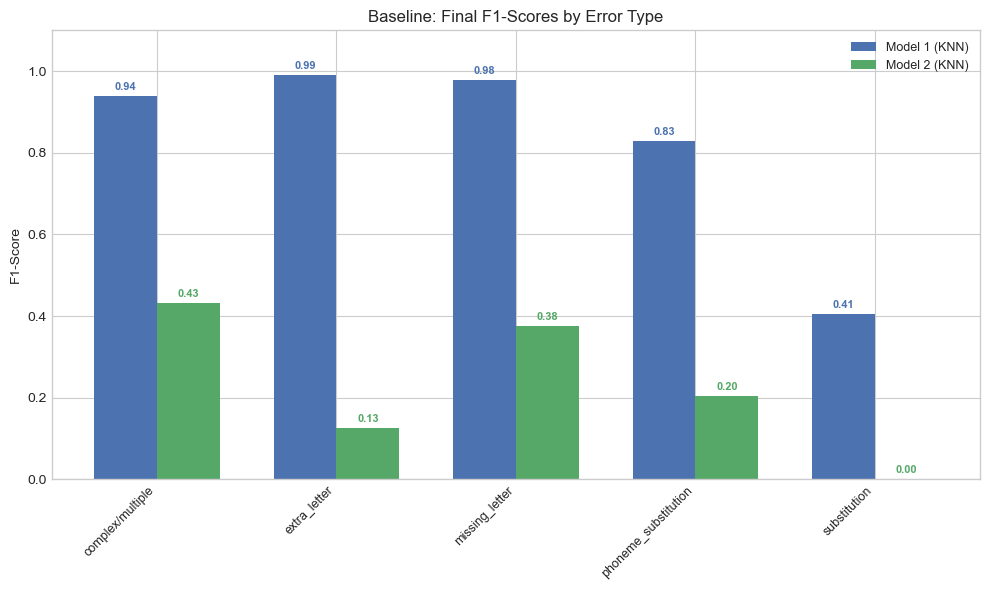

In [23]:
# Plot: Proof-of-Concept Final F1-Scores by Error Type (Model 1 vs Model 2)
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

# Build per-class F1 for Model 1 using the same test records
report_m1 = classification_report(y_test, y_pred_m1, output_dict=True, zero_division=0)

# Build per-class F1 for Model 2 using argmax profiles (already computed)
report_m2 = classification_report(y_true_hard_proxy, y_pred_hard_proxy, output_dict=True, zero_division=0)

# Keep a stable class order and readable labels
categories = [
    'complex/multiple',
    'extra_letter',
    'missing_letter',
    'phoneme_substitution',
    'substitution',
]

f1_m1 = [report_m1.get(c, {}).get('f1-score', 0.0) for c in categories]
f1_m2 = [report_m2.get(c, {}).get('f1-score', 0.0) for c in categories]

x = np.arange(len(categories))
width = 0.35

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width / 2, f1_m1, width, label='Model 1 (KNN)', color='#4C72B0')
bars2 = ax.bar(x + width / 2, f1_m2, width, label='Model 2 (KNN)', color='#55A868')

ax.set_title('Baseline: Final F1-Scores by Error Type')
ax.set_ylabel('F1-Score')
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 1.1)
ax.legend(loc='upper right', fontsize=9)

# value labels on bars
for bars in (bars1, bars2):
    for b in bars:
        h = b.get_height()
        ax.text(
            b.get_x() + b.get_width() / 2,
            h + 0.01,
            f'{h:.2f}',
            ha='center',
            va='bottom',
            fontsize=8,
            color='#4C72B0' if bars is bars1 else '#55A868',
            fontweight='bold'
        )

fig.tight_layout()
plt.show()